<a href="https://colab.research.google.com/github/Bhuvana908/ML-Projects/blob/main/Named_Entity_Recognition_using_Bidirectional_LSTM/Named_Entity_Recognition_using_Bidirectional_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
!pip install seqeval sklearn-crfsuite

In [32]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import LSTM, Dense, TimeDistributed, Embedding, Bidirectional, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn_crfsuite.metrics import flat_classification_report
from seqeval.metrics import precision_score, recall_score, f1_score, classification_report

import matplotlib.pyplot as plt
%matplotlib inline

import pickle

In [33]:
from google.colab import files
uploaded = files.upload()

Saving ner_dataset.csv to ner_dataset (1).csv


In [34]:
df = pd.read_csv("ner_dataset.csv", encoding="latin1")
df.head(20)

,Sentence #,Word,POS,Tag
0,Sentence: 1,Thousands,NNS,O
1,NaN,of,IN,O
2,NaN,demonstrators,NNS,O
3,NaN,have,VBP,O
4,NaN,marched,VBN,O
5,NaN,through,IN,O
6,NaN,London,NNP,B-geo
7,NaN,to,TO,O
8,NaN,protest,VB,O
9,NaN,the,DT,O


In [35]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
df.info()

Shape: (1048575, 4)

Columns: ['Sentence #', 'Word', 'POS', 'Tag']

Missing Values:
 Sentence #    1000616
Word               10
POS                 0
Tag                 0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 4 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Sentence #  47959 non-null    object
 1   Word        1048565 non-null  object
 2   POS         1048575 non-null  object
 3   Tag         1048575 non-null  object
dtypes: object(4)
memory usage: 32.0+ MB


In [36]:
df.fillna(method='ffill', inplace=True)

print("Unique Tags:\n", df['Tag'].value_counts())
print("\nTotal Unique Words:", df['Word'].nunique())
print("Total Unique Tags:", df['Tag'].nunique())

Unique Tags:
 Tag
O        887908
B-geo     37644
B-tim     20333
B-org     20143
I-per     17251
B-per     16990
I-org     16784
B-gpe     15870
I-geo      7414
I-tim      6528
B-art       402
B-eve       308
I-art       297
I-eve       253
B-nat       201
I-gpe       198
I-nat        51
Name: count, dtype: int64

Total Unique Words: 35177
Total Unique Tags: 17


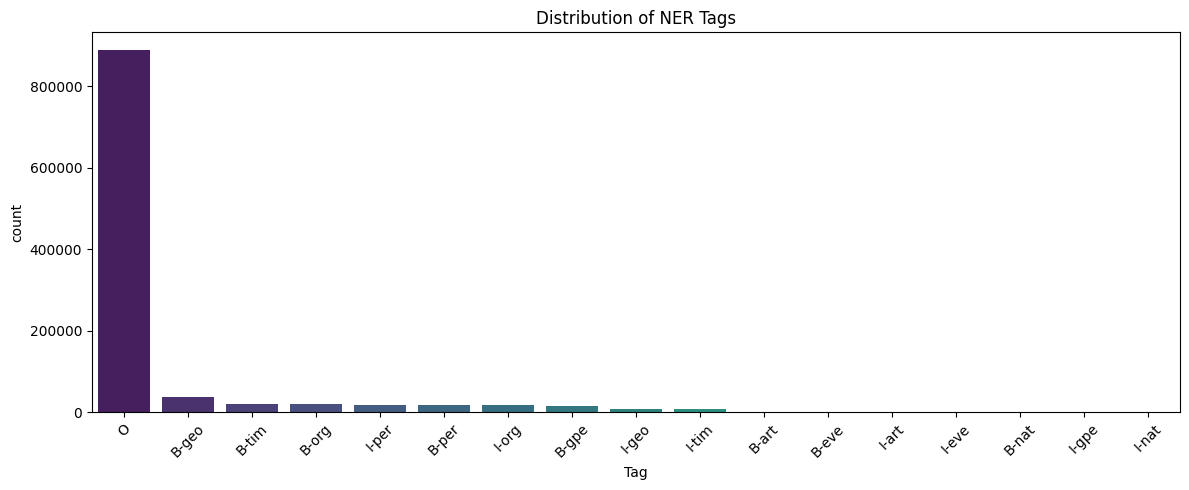

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))
sns.countplot(x='Tag', data=df, order=df['Tag'].value_counts().index, palette='viridis')
plt.title('Distribution of NER Tags')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
words = list(df['Word'].unique())
tags  = list(df['Tag'].unique())

words.append("ENDPAD")

num_words = len(words)
num_tags  = len(tags)

print(f"Unique Words: {num_words}")
print(f"Unique Tags : {num_tags}")
print(f"Tags: {tags}")

word2idx = {w: i+1 for i, w in enumerate(words)}
tag2idx  = {t: i   for i, t in enumerate(tags)}

print("\nTag to Index Mapping:\n", tag2idx)

Unique Words: 35178
Unique Tags : 17
Tags: ['O', 'B-geo', 'B-gpe', 'B-per', 'I-geo', 'B-org', 'I-org', 'B-tim', 'B-art', 'I-art', 'I-per', 'I-gpe', 'I-tim', 'B-nat', 'B-eve', 'I-eve', 'I-nat']

Tag to Index Mapping:
 {'O': 0, 'B-geo': 1, 'B-gpe': 2, 'B-per': 3, 'I-geo': 4, 'B-org': 5, 'I-org': 6, 'B-tim': 7, 'B-art': 8, 'I-art': 9, 'I-per': 10, 'I-gpe': 11, 'I-tim': 12, 'B-nat': 13, 'B-eve': 14, 'I-eve': 15, 'I-nat': 16}


In [39]:
class SentenceGetter:
    def __init__(self, data):
        self.data = data
        agg_func = lambda s: [(w, t) for w, t in zip(
            s['Word'].values.tolist(),
            s['Tag'].values.tolist()
        )]
        self.grouped   = self.data.groupby('Sentence #').apply(agg_func)
        self.sentences = [s for s in self.grouped]

getter    = SentenceGetter(df)
sentences = getter.sentences

print(f"Total Sentences: {len(sentences)}")
print(f"\nExample Sentence:\n{sentences[0]}")

Total Sentences: 47959

Example Sentence:
[('Thousands', 'O'), ('of', 'O'), ('demonstrators', 'O'), ('have', 'O'), ('marched', 'O'), ('through', 'O'), ('London', 'B-geo'), ('to', 'O'), ('protest', 'O'), ('the', 'O'), ('war', 'O'), ('in', 'O'), ('Iraq', 'B-geo'), ('and', 'O'), ('demand', 'O'), ('the', 'O'), ('withdrawal', 'O'), ('of', 'O'), ('British', 'B-gpe'), ('troops', 'O'), ('from', 'O'), ('that', 'O'), ('country', 'O'), ('.', 'O')]


In [40]:
MAX_LEN = 50

X = [[word2idx.get(w[0], 0) for w in s] for s in sentences]
y = [[tag2idx[w[1]]          for w in s] for s in sentences]

X = pad_sequences(maxlen=MAX_LEN, sequences=X, padding='post', value=word2idx["ENDPAD"])
y = pad_sequences(maxlen=MAX_LEN, sequences=y, padding='post', value=tag2idx['O'])

y = to_categorical(y, num_classes=num_tags)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (47959, 50)
y shape: (47959, 50, 17)


In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (38367, 50)
X_test : (9592, 50)
y_train: (38367, 50, 17)
y_test : (9592, 50, 17)


In [42]:
from tensorflow.keras.layers import Dropout

In [43]:
input_layer = Input(shape=(MAX_LEN,))

x = Embedding(input_dim=num_words+1, output_dim=64, input_length=MAX_LEN)(input_layer)
x = Dropout(0.1)(x)
x = Bidirectional(LSTM(units=100, return_sequences=True, recurrent_dropout=0.1))(x)
output = TimeDistributed(Dense(num_tags, activation='softmax'))(x)

model = Model(input_layer, output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_4 (Embedding)         │ (None, 50, 64)         │     2,251,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 50, 200)        │       132,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 50, 17)         │         3,417 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,386,873 (9.11 MB)

 Trainable params: 2,386,873 (9.11 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
history = model.fit(
    X_train, y_train,
    batch_size=64,
    epochs=5,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
540/540 ━━━━━━━━━━━━━━━━━━━━ 174s 305ms/step - accuracy: 0.9286 - loss: 0.3958 - val_accuracy: 0.9783 - val_loss: 0.0775
Epoch 2/5
540/540 ━━━━━━━━━━━━━━━━━━━━ 200s 301ms/step - accuracy: 0.9819 - loss: 0.0635 - val_accuracy: 0.9834 - val_loss: 0.0560
Epoch 3/5
540/540 ━━━━━━━━━━━━━━━━━━━━ 162s 299ms/step - accuracy: 0.9876 - loss: 0.0419 - val_accuracy: 0.9851 - val_loss: 0.0491
Epoch 4/5
540/540 ━━━━━━━━━━━━━━━━━━━━ 198s 292ms/step - accuracy: 0.9897 - loss: 0.0335 - val_accuracy: 0.9853 - val_loss: 0.0483
Epoch 5/5
540/540 ━━━━━━━━━━━━━━━━━━━━ 160s 296ms/step - accuracy: 0.9911 - loss: 0.0285 - val_accuracy: 0.9851 - val_loss: 0.0490


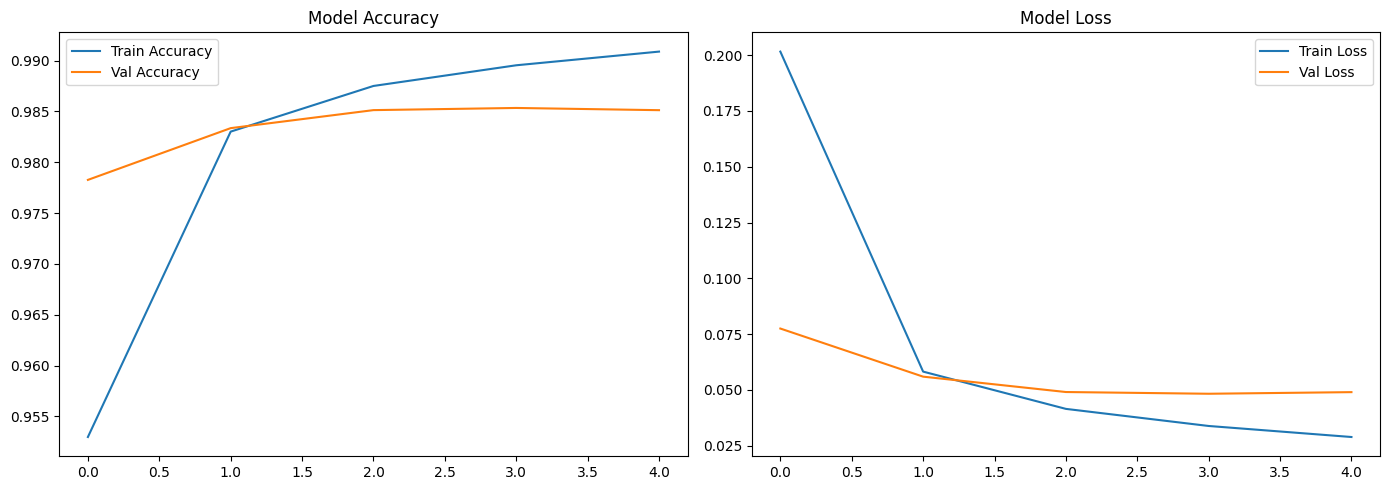

In [45]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [46]:
y_pred = model.predict(X_test)

y_pred_labels = np.argmax(y_pred,  axis=-1)
y_true_labels = np.argmax(y_test,  axis=-1)

idx2tag = {v: k for k, v in tag2idx.items()}

y_pred_flat = [[idx2tag[i] for i in row] for row in y_pred_labels]
y_true_flat = [[idx2tag[i] for i in row] for row in y_true_labels]

print(classification_report(y_true_flat, y_pred_flat))

300/300 ━━━━━━━━━━━━━━━━━━━━ 14s 42ms/step
              precision    recall  f1-score   support

         art       0.00      0.00      0.00        94
         eve       0.54      0.21      0.31        70
         geo       0.82      0.89      0.85      7556
         gpe       0.97      0.93      0.94      3137
         nat       1.00      0.05      0.10        40
         org       0.66      0.67      0.66      4149
         per       0.74      0.74      0.74      3397
         tim       0.86      0.84      0.85      4074

   micro avg       0.80      0.81      0.81     22517
   macro avg       0.70      0.54      0.56     22517
weighted avg       0.80      0.81      0.81     22517



The BiLSTM model achieved a weighted F1-score of 0.81, performing well on frequent entity types like geo (0.86), gpe (0.95), and tim (0.86). However, rare tags like art, nat, and eve scored poorly (0.00, 0.05, 0.32) due to severe class imbalance, where dominant tags had thousands of samples while rare tags had fewer than 100. The model learned to ignore rare tags since predicting them wrong had minimal impact on the overall loss. Future improvements could include collecting more data for rare entities or using a pretrained model like BERT for better generalization.

In [47]:
def predict_entities(sentence: str):
    words_in = sentence.strip().split()
    encoded  = [word2idx.get(w, 0) for w in words_in]
    padded   = pad_sequences([encoded], maxlen=MAX_LEN, padding='post')
    preds    = model.predict(padded)[0]
    tags_out = [idx2tag[np.argmax(p)] for p in preds[:len(words_in)]]

    print(f"\n{'Word':<20} {'Tag'}")
    print("-" * 30)
    for word, tag in zip(words_in, tags_out):
        print(f"{word:<20} {tag}")

# Test
predict_entities("Barack Obama visited Paris in June 2023")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step

Word                 Tag
------------------------------
Barack               B-per
Obama                I-per
visited              O
Paris                B-geo
in                   O
June                 B-tim
2023                 I-tim
